### LangGraph (mini-graph of states)

In [1]:
# (setup cell already installs what this notebook needs)
!apt install libgraphviz-dev
!pip install pygraphviz

'pip' is not recognized as an internal or external command,
operable program or batch file.
'apt' is not recognized as an internal or external command,
operable program or batch file.
'pip' is not recognized as an internal or external command,
operable program or batch file.


Run the next cell first. In Colab, add the course key under the key
icon in the left sidebar as `COURSE_API_KEY`, with *Notebook access* on.

In [ ]:
# Course setup. In Colab: add the course key under the key icon (left sidebar)
# as COURSE_API_KEY. On your own machine it uses Ollama instead.
import os
import sys
import subprocess

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # Pinned, including the transitive ones. Unpinned, pip takes whatever
    # shipped this morning : a newer core moves ModelError, and a newer openai
    # rejects this endpoint's usage payload. Keep in step with requirements.txt.
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "langchain==1.3.9", "langchain-core==1.4.7",
                    "langchain-openai==1.3.2", "langchain-classic==1.0.8",
                    "langgraph==1.2.5", "openai==2.41.1", "python-dotenv"],
                   check=True)
    MODEL = "qwen3.8-flash"          # try qwen3.8-max too
    BASE = "https://token-plan.ap-southeast-1.maas.aliyuncs.com/compatible-mode/v1"
    THINKING = {"enable_thinking": False}
    KEY = os.getenv("COURSE_API_KEY")
    if not KEY:
        try:
            from google.colab import userdata
            KEY = userdata.get("COURSE_API_KEY")   # raises if unset or not shared
        except Exception:
            import getpass
            KEY = getpass.getpass("Course key (paste the one from the trainer): ")
else:
    from dotenv import load_dotenv
    load_dotenv()
    MODEL = "qwen3.5:2b"             # try qwen3.5:4b too
    BASE = "http://localhost:11434/v1"
    KEY = "ollama"
    THINKING = {"reasoning_effort": "none"}

from langchain_openai import ChatOpenAI


def make_llm(**kw):
    kw.setdefault("temperature", 0)
    kw.setdefault("model", MODEL)
    kw.setdefault("extra_body", THINKING)
    return ChatOpenAI(base_url=BASE, api_key=KEY, **kw)


def make_embeddings(**kw):
    # The course endpoint has no embeddings, so they run here instead. 90 MB,
    # installed only by the notebooks that actually ask for them.
    try:
        from langchain_huggingface import HuggingFaceEmbeddings
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                        "langchain-huggingface==0.3.1"], check=True)
        from langchain_huggingface import HuggingFaceEmbeddings
    kw.setdefault("model_name", "sentence-transformers/all-MiniLM-L6-v2")
    return HuggingFaceEmbeddings(**kw)


DATA_URL = ("https://raw.githubusercontent.com/FeikoWielsma/"
            "Building-AI-Agents/main/data/")


def data(name):
    """Path to a course data file. Downloads it in Colab, local copy otherwise."""
    if os.path.exists(f"../data/{name}"):
        return f"../data/{name}"
    if not os.path.exists(name):
        import urllib.request
        urllib.request.urlretrieve(DATA_URL + name, name)
    return name


llm = make_llm()
print(f"model={MODEL}")

In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, END
from dotenv import load_dotenv

load_dotenv()

True

### State

In [3]:
class State(TypedDict):
    x: int

### Nodes definitions

In [4]:
def add_one(state: State) -> State:
    return {"x": state["x"] + 1}

def multiply_by_two(state: State) -> State:
    return {"x": state["x"] * 2}

def finish(state: State) -> State:
    print(f"Result {state['x']}")
    return state

### Graph structure

In [5]:
graph = StateGraph(State)

# define nodes
graph.add_node("A", add_one)
graph.add_node("B", multiply_by_two)
graph.add_node("C", finish)

# define edges
graph.set_entry_point("A")
graph.add_edge("A", "B")
graph.add_edge("B", "C")
graph.add_edge("C", END)

### Compile and run the graph

In [6]:
app = graph.compile()

result = app.invoke({"x": 1})
print(result)

Result 4
{'x': 4}


### Display graph

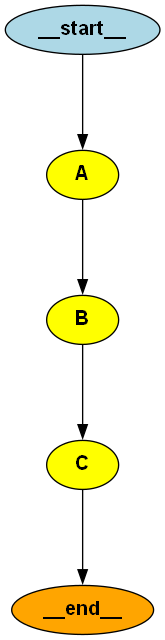

In [7]:
from IPython.display import Image, display

png_bytes = app.get_graph().draw_png()
display(Image(png_bytes))

### Hello LangGraph

In [20]:
from typing import TypedDict
from langgraph.graph import StateGraph, END
import warnings
warnings.filterwarnings("ignore", message=".*allowed_objects.*")

class SimpleState(TypedDict):
    value: int

def double(state: SimpleState) -> dict:
    return {"value": state["value"] * 2}

def add_ten(state: SimpleState) -> dict:
    return {"value": state["value"] + 10}

# Build the graph
builder = StateGraph(SimpleState)
builder.add_node("double", double)
builder.add_node("add_ten", add_ten)

# Edges
builder.set_entry_point("double")
builder.add_edge("double", "add_ten")
builder.add_edge("add_ten", END)

# Compile
graph = builder.compile()

# Invoke
result = graph.invoke({"value": 5})
print(result)  # {'value': 20}  (5*2 + 10)

{'value': 20}


### Conditional Edges
A conditional edge is how we put branching and loops into a LangGraph graph. Where a normal edge (add_edge("a", "b")) always sends flow from one node to a fixed next node, a conditional edge runs a small routing function at execution time, inspects the current state, and decides where to go next.
Mechanically there are two pieces: a router function that takes the state and returns a string, and the add_conditional_edges call that wires it up:

In [34]:
from typing import Literal
from typing import TypedDict
from langgraph.graph import StateGraph, END

class State(TypedDict):
    score: int
    verdict: str

def evaluate(state: State) -> dict:
    return {"verdict": "pass" if state["score"] >= 60 else "fail"}

def on_pass(state: State) -> dict:
    return {"verdict": "Congratulations! You passed."}

def on_fail(state: State) -> dict:
    return {"verdict": "Sorry, you failed. Please retry."}

def route(state: State) -> Literal["pass_node", "fail_node"]:
    return "pass_node" if state["verdict"] == "pass" else "fail_node"

builder = StateGraph(State)
builder.add_node("evaluate", evaluate)
builder.add_node("pass_node", on_pass)
builder.add_node("fail_node", on_fail)

builder.set_entry_point("evaluate")
builder.add_conditional_edges("evaluate", route)  # calls route(state)
builder.add_edge("pass_node", END)
builder.add_edge("fail_node", END)

graph = builder.compile()
print(graph.invoke({"score": 75, "verdict": ""}))
print(graph.invoke({"score": 40, "verdict": ""}))

{'score': 75, 'verdict': 'Congratulations! You passed.'}
{'score': 40, 'verdict': 'Sorry, you failed. Please retry.'}


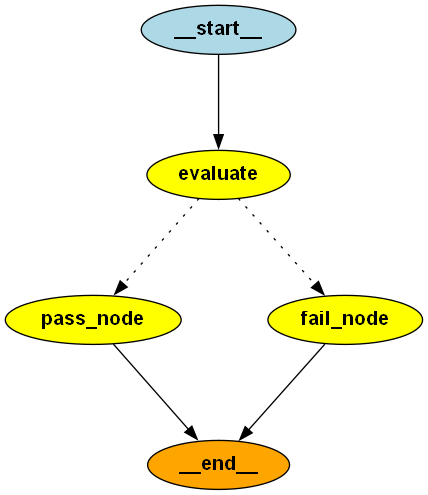

b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01\r\x00\x00\x01M\x08\x02\x00\x00\x00\x95(\xad3\x00\x00\x10\x00IDATx\x9c\xec\x9d\x07@\x13g\xff\xc7\x9fKBB\xd8\xa0 \x08(\xb8\xb5*N\xdc{\xd5\xbd\xb0\xf6uTqkU\xdcu\xb5\xae\xd6Zg\xeb\xfe[\xb5\xd6m\xabh]\xad{\x0b\xce\xe2\x1ee\xb9X\xb2w\xe6\xfd\x7f\x97\x83\xb0\x12 j\xf4.\xf9}\xde\xbe\xf1\xf2<wIx\x9e\xfb>\xbf\xf1\xdc=\'\xa2i\x9a \x08R,"\x82 HI\xa0N\x10\xa4dP\'\x08R2\xa8\x13\x04)\x19\xd4\t\x82\x94\x0c\xea\x04AJ\x06uRZ\xa2#\xb2\x1e\x07\xa7&\xc6\xc8\x94JZ\xad\xa2\x94\n\xb5@H\xa9U\xb4@@\xa9\xd5\xb4PD\xa9\x94L\x86\x9d\xa2\x08d\xda\xa1\x10\xb6\x99r!\xa5R\xe5d\xde\xd9*\xf8\x97\x10\xe6\x1f\xf6@\xf6C\xb4\xdf\xa2=\x1c\xaa\xf2\x1d\xc2\xa0\xdd\x93\xa2\tMA\x15\xc5\xe6\xf4)\x01E\xab\x0blh\x11K(\x81\x90Hm\x84n\xde\x96\x8d;\x97%\xc8\xbbB\xe1\xfcI\xf1\x84=H\xbdv4!5A\x05\xe7\xb6PD\xc4\x96\x02\x89\x95\x00\xca\xd5\n\x8a\x12\x10ZM\xd8W\x81\x88\xa8\x95\x9a\x034*\x80B8\x8f\xe1\xb4fks\xd0T\xd1\x9a\x7f\x99w\xec\x81B\x90\x13+\x1c\xa6\x92b\x94A(!\xa1Uy\x87\xe4\x1c\x9d[\xa8

In [ ]:

png_bytes = graph.get_graph().draw_png()
display(Image(png_bytes))


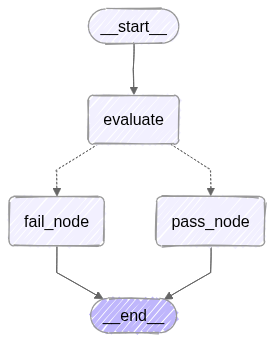

In [46]:
display(Image(graph.get_graph().draw_mermaid_png(
    frontmatter_config={"config":
                        {
                            "theme": "neutral",
                            "look": "handDrawn",
                            "themeVariables": {"primaryColor": "#11d37f"}
                        }
}) ))

### Reducers
A reducer is a function attached to a particular key in our graph state that defines how an update to that key gets merged into the existing value. Every field in our state is really a channel, and the reducer is the channel's merge policy : it answers "when a node returns a new value for this field, do I overwrite what's there, or combine the two?"
The default, when we don't specify a reducer, is overwrite: if a node returns {"foo": x}, the old value of foo is simply replaced by x. That's fine for scalars like a counter or a status flag, but it's exactly the wrong behavior for something like message history ; we don't want each node to clobber the whole conversation.
We attach a reducer with Annotated, pairing the field's type with the merge function:
Both nodes return the exact same shape, a one-item list plus a string, but the two fields behave completely differently:
collected has the operator.add reducer, so each node's update is concatenated: [] + ["a"] + ["b"] ends up as ["a", "b"]. Notice each node only returns its own item (["a"]), never the running total ; the reducer does the combining.
last has no reducer, so it uses the default overwrite. node_b's value simply replaces node_a's, and only "b" survives.
That single print output, an accumulated list next to an overwritten scalar from identically-shaped node returns, is usually the moment the concept clicks for a class. From here operator.add swaps cleanly for add_messages to show the same append behavior on real message objects, if we want to bridge to the agent examples.

In [49]:
import operator
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class State(TypedDict):
    #collected: Annotated[list[str], operator.add]   # reducer: concatenate
    collected: Annotated[list[str], add_messages]   # reducer: concatenate
    last: str                                       # no reducer: overwrite
def node_a(state: State) -> dict:
    return {"collected": ["a"], "last": "a"}
def node_b(state: State) -> dict:
    return {"collected": ["b"], "last": "b"}

builder = StateGraph(State)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_edge(START, "node_a")
builder.add_edge("node_a", "node_b")
builder.add_edge("node_b", END)

graph = builder.compile()

result = graph.invoke({"collected": [], "last": ""})
print(result)
# {'collected': ['a', 'b'], 'last': 'b'}

{'collected': [HumanMessage(content='a', additional_kwargs={}, response_metadata={}, id='a2633799-acca-46cd-a139-3323355d4261'), HumanMessage(content='b', additional_kwargs={}, response_metadata={}, id='9070f2ad-13ad-4b08-b560-a515fe4a95ab')], 'last': 'b'}


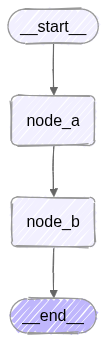

In [48]:
display(Image(graph.get_graph().draw_mermaid_png(
    frontmatter_config={"config":
                        {
                            "theme": "neutral",
                            "look": "handDrawn",
                            "themeVariables": {"primaryColor": "#11d37f"}
                        }
}) ))

### Loops or Cycles
In LangGraph there's no special "loop" construct ; a loop is an edge that points back to a node the graph has already visited. Because a LangGraph graph is a directed graph that's allowed to contain cycles, we create a loop just by adding an edge from a later node back to an earlier one. The piece that makes the loop terminate is a conditional edge somewhere in the cycle whose router decides "go around again" versus "exit." So loops are really the two things from our last question working together: a conditional edge for the branch, and an ordinary edge pointing backward for the cycle.

In [ ]:
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, END
import operator

class LoopState(TypedDict):
    counter: int
    messages: Annotated[list[str], operator.add]

def increment(state: LoopState) -> dict:
    return {
        "counter": state["counter"] + 1,              # change to 0 to get a recursion error
        "messages": [f"Step {state['counter'] + 1}"],
    }

def should_continue(state: LoopState) -> str:
    print("IN ROUTER")
    if state["counter"] < 5:
        return "increment"
    return END

builder = StateGraph(LoopState)
builder.add_node("increment", increment)
builder.set_entry_point("increment")
builder.add_conditional_edges("increment", should_continue)

graph = builder.compile()
result = graph.invoke({"counter": 0, "messages": []})
print(result["counter"])   # 5
print(result["messages"])  # ['Step 1', ..., 'Step 5']

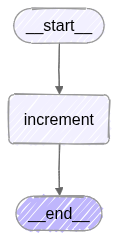

In [56]:
display(Image(graph.get_graph().draw_mermaid_png(
    frontmatter_config={"config":
                        {
                            "theme": "neutral",
                            "look": "handDrawn",
                            "themeVariables": {"primaryColor": "#11d37f"}
                        }
}) ))

### MessagesState 
MessagesState is just a prebuilt convenience. It's a TypedDict that LangGraph ships with a single key already defined for us : exactly the annotation we have been writing by hand. Saves we from redeclaring the messages field with its add_messages reducer in every chat or agent graph. So reaching for MessagesState is identical to writing that custom State class. Has same append-not-overwrite behavior on messages ; we don't have to type the annotation.

In [24]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_core.messages import HumanMessage, AIMessage

def user_says(state: MessagesState) -> dict:
    return {"messages": [HumanMessage(content="What time is it?")]}

def bot_replies(state: MessagesState) -> dict:
    last = state["messages"][-1].content          # read what's already in state
    return {"messages": [AIMessage(content=f"You asked: {last!r}, but I'm a rule, not an LLM.")]}

builder = StateGraph(MessagesState)
builder.add_node("user_says", user_says)
builder.add_node("bot_replies", bot_replies)
builder.add_edge(START, "user_says")
builder.add_edge("user_says", "bot_replies")
builder.add_edge("bot_replies", END)

graph = builder.compile()

result = graph.invoke({"messages": []})

for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

What time is it?
================================== Ai Message ==================================

You asked: 'What time is it?' — but I'm a rule, not an LLM.


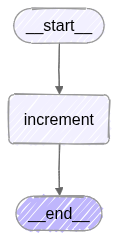

In [53]:
display(Image(graph.get_graph().draw_mermaid_png(
    frontmatter_config={"config":
                        {
                            "theme": "neutral",
                            "look": "handDrawn",
                            "themeVariables": {"primaryColor": "#11d37f"}
                        }
}) ))

### InMemorySaver
Conceptually, InMemorySaver is the simplest checkpointer. A checkpointer saves a checkpoint of the graph state at every superstep, keyed by a thread ID, which is what gives a graph memory between separate .invoke() calls, plus enables human-in-the-loop, time travel, and fault recovery. InMemorySaver is the trivial implementation that keeps those checkpoints in a plain dict in RAM, so it's meant for debugging or testing; for production we would install langgraph-checkpoint-postgres and use PostgresSaver (or SqliteSaver for local persistence). Same interface, so swapping is a one-liner.

In [ ]:
import operator
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver   # MemorySaver = older alias
from langchain_core.runnables.config import RunnableConfig

class State(TypedDict):
    visits: Annotated[list[str], operator.add]


def record_visit(state: State) -> dict:
    n = len(state["visits"]) + 1
    return {"visits": [f"visit #{n}"]}


builder = StateGraph(State)
builder.add_node("record_visit", record_visit)
builder.add_edge(START, "record_visit")
builder.add_edge("record_visit", END)


# --- Without a checkpointer: no memory ---
plain = builder.compile()
print(plain.invoke({"visits": []})["visits"])   # ['visit #1']
print(plain.invoke({"visits": []})["visits"])   # ['visit #1']   <- forgets every time


# --- With InMemorySaver: state persists per thread_id ---
graph = builder.compile(checkpointer=InMemorySaver())

einstein = RunnableConfig({"configurable": {"thread_id": "einstein"}})
print(graph.invoke({"visits": []}, einstein)["visits"])  # ['visit #1']
print(graph.invoke({"visits": []}, einstein)["visits"])  # ['visit #1', 'visit #2']
print(graph.invoke({"visits": []}, einstein)["visits"])  # ['visit #1', 'visit #2', 'visit #3']

heisenberg = {"configurable": {"thread_id": "heisenberg"}}
print(graph.invoke({"visits": []}, heisenberg)["visits"])    # ['visit #1']              <- different thread, blank slate
print(graph.invoke({"visits": []}, heisenberg)["visits"])    # ['visit #1', visit #2']   

# Inspect the stored checkpoint directly:
print(graph.get_state(einstein).values["visits"])          # ['visit #1', 'visit #2', 'visit #3']
print(graph.get_state(heisenberg).values["visits"])        # ['visit #1', 'visit #2', 'visit #3']

['visit #1']
['visit #1']
['visit #1']
['visit #1', 'visit #2']
['visit #1', 'visit #2', 'visit #3']
['visit #1']
['visit #1', 'visit #2']
['visit #1', 'visit #2', 'visit #3']
['visit #1', 'visit #2']


### Agent Single Pass
Consider a hand-wired agent with a single forward pass : the LLM still autonomously decides which tool to call, but after the tools run, the flow goes forward to a final answer node instead of looping back. It's a real agent (the model chooses the tools), just not an iterative one. After the Single Pass agent we will consider an Agent with a loop.
Both graphs share the same start. The agent node runs, the model reads "Where is order ORD-4471?", and it correctly reasons that it can't answer directly ; it needs a tracking number first. So it emits one tool call, find_parcel("ORD-4471"). The tools node runs it and appends the result, 3SDHL9924871, to the message list. Up to this point the two graphs are identical. What differs is the single edge that decides where control goes after the tool runs.
Single pass : tools → final → END. After find_parcel returns, control moves forward to the final node. That node calls the model with no tools bound, so whatever the model says there, it cannot make another tool call ; the binding that would let it invoke read_parcel is not present. The model now holds the tracking number and knows exactly what it wants to do with it, but it has no mechanism to act: final can only produce text, then the graph hits END. The result is the stuck output we saw : it discovered the ID and stalled one step short of the answer. The structural reason is that a single pass gives the model exactly one opportunity to call tools (the first agent node), and that opportunity was spent discovering the ID. There's no second opportunity to use it.


In [ ]:
from typing import Annotated
from typing_extensions import TypedDict

from langchain_core.tools import tool
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage
from langchain_openai import ChatOpenAI

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

import warnings
warnings.filterwarnings("ignore", message=".*allowed_objects.*")

@tool
def find_parcel(order_ref: str) -> str:
    """Return the carrier tracking number for an order reference. This number
    is internal : it cannot be known or guessed without calling this tool."""
    parcels = {"ord-4471": "3SDHL9924871", "ord-5510": "3SDHL7741203",
               "ord-6082": "3SDHL5518860"}
    key = order_ref.strip().lower()
    if key not in parcels:
        raise ValueError(f"No parcel for {order_ref!r}.")
    return parcels[key]


@tool
def read_parcel(tracking_id: str) -> str:
    """Delivery status for a tracking number from find_parcel. Does NOT
    accept order references."""
    statuses = {"3SDHL9924871": "at the Utrecht depot, out for delivery today",
                "3SDHL7741203": "held at customs since Tuesday",
                "3SDHL5518860": "delivered, signed for by R. Jansen"}
    if tracking_id not in statuses:
        raise ValueError(f"Unknown tracking number {tracking_id!r}.")
    return statuses[tracking_id]

tools = [find_parcel, read_parcel]

SYSTEM = SystemMessage(content=(
    "You are a parcel assistant. To get a delivery status you must FIRST call "
    "find_parcel for the city, THEN pass the returned tracking number to "
    "read_parcel. You cannot know tracking numbers or delivery statuses yourself; "
    "never invent either : every value must come from a tool result."
))

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

llm = make_llm()
llm_with_tools = llm.bind_tools(tools)

def agent(state: State) -> dict:
    return {"messages": [llm_with_tools.invoke([SYSTEM, *state["messages"]])]}

def final(state: State) -> dict:                      # plain llm, no tools bound
    return {"messages": [llm.invoke([SYSTEM, *state["messages"]])]}

# --- Single-pass graph: tools -> final -> END ---
sp = StateGraph(State)
sp.add_node("agent", agent); sp.add_node("tools", ToolNode(tools)); sp.add_node("final", final)
sp.add_edge(START, "agent")
sp.add_conditional_edges("agent", tools_condition)
sp.add_edge("tools", "final")                          # forward, no loop
sp.add_edge("final", END)
single_pass_graph = sp.compile()

q = {"messages": [HumanMessage(content="Where is order ORD-4471?")]}

print("\n========== SINGLE PASS ==========")
for m in single_pass_graph.invoke(q)["messages"]: m.pretty_print()

### Agent Loop 
Loop : tools → agent → …. After find_parcel returns, control goes back to the agent node instead of forward. Now the model runs again, and this time its message history already contains the tracking number 3SDHL9924871. With that value in hand, and with tools still bound, it can form the call it couldn't before: read_parcel("3SDHL9924871"). That routes through tools_condition to the tools node, read_parcel returns the status, and control loops back to the agent a third time. On this final pass the model has the delivery status, has nothing left to look up, and so emits a plain text answer with no tool calls. tools_condition sees no tool calls and routes to END. Three passes through the agent: discover, use, answer.
The one sentence that captures it: the dependency is sequential, read_parcel's argument is find_parcel's output, and a sequential dependency needs one agent turn per step, because the model can't write down a tool call whose argument doesn't exist yet. The single pass allows exactly one tool-calling turn, so it can handle at most one step of a chain. The loop supplies a fresh turn each time a tool result comes back, so the chain can be as long as it needs to be. The loop back is precisely what converts "one shot at calling tools" into "as many shots as the problem requires."

In [ ]:
from typing import Annotated
from typing_extensions import TypedDict

from langchain_core.tools import tool
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage
from langchain_openai import ChatOpenAI

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

import warnings
warnings.filterwarnings("ignore", message=".*allowed_objects.*")

@tool
def find_parcel(order_ref: str) -> str:
    """Return the carrier tracking number for an order reference. This number
    is internal : it cannot be known or guessed without calling this tool."""
    parcels = {"ord-4471": "3SDHL9924871", "ord-5510": "3SDHL7741203",
               "ord-6082": "3SDHL5518860"}
    key = order_ref.strip().lower()
    if key not in parcels:
        raise ValueError(f"No parcel for {order_ref!r}.")
    return parcels[key]


@tool
def read_parcel(tracking_id: str) -> str:
    """Delivery status for a tracking number from find_parcel. Does NOT
    accept order references."""
    statuses = {"3SDHL9924871": "at the Utrecht depot, out for delivery today",
                "3SDHL7741203": "held at customs since Tuesday",
                "3SDHL5518860": "delivered, signed for by R. Jansen"}
    if tracking_id not in statuses:
        raise ValueError(f"Unknown tracking number {tracking_id!r}.")
    return statuses[tracking_id]

tools = [find_parcel, read_parcel]

SYSTEM = SystemMessage(content=(
    "You are a parcel assistant. To get a delivery status you must FIRST call "
    "find_parcel for the city, THEN pass the returned tracking number to "
    "read_parcel. You cannot know tracking numbers or delivery statuses yourself; "
    "never invent either : every value must come from a tool result."
))

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

llm = make_llm()
llm_with_tools = llm.bind_tools(tools)

def agent(state: State) -> dict:
    return {"messages": [llm_with_tools.invoke([SYSTEM, *state["messages"]])]}

def final(state: State) -> dict:                      # plain llm, no tools bound
    return {"messages": [llm.invoke([SYSTEM, *state["messages"]])]}

# --- Loop graph: tools -> agent ---
lb = StateGraph(State)
lb.add_node("agent", agent); lb.add_node("tools", ToolNode(tools))
lb.add_edge(START, "agent")
lb.add_conditional_edges("agent", tools_condition)
lb.add_edge("tools", "agent")                          # loops back
loop_graph = lb.compile()

q = {"messages": [HumanMessage(content="Where is order ORD-4471?")]}

print("========== LOOP ==========")
for m in loop_graph.invoke(q)["messages"]: m.pretty_print()

### ReAct Agent
create_agent produces the identical three-lap trace as our loop_graph, find_parcel → read_parcel → answer, because under the hood it is the loop graph we built. The agent node calls the model; if the reply contains tool calls, the tools node runs them and appends the results, then the model is called again, repeating until no tool calls remain. We pass the plain llm (not llm_with_tools) because create_agent binds the tools for us, and model= also accepts a shorthand string like "openai:gpt-5.6-luna" instead of an instance. The returned object is a compiled graph with the same invoke/stream interface and the same {"messages": [...]} shape we have been using. That closes the arc nicely: single-pass (fails on dependencies) → hand-built loop (works, and we can see every edge) → create_agent (the same loop, one line, once we understand what it's hiding). 

In [ ]:
import warnings
warnings.filterwarnings("ignore", message=".*allowed_objects.*")

from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent


# --- Tools: opaque intermediate the model can't guess ---
@tool
def find_parcel(order_ref: str) -> str:
    """Return the carrier tracking number for an order reference."""
    parcels = {"ord-4471": "3SDHL9924871", "ord-5510": "3SDHL7741203",
               "ord-6082": "3SDHL5518860"}
    key = order_ref.strip().lower()
    if key not in parcels:
        raise ValueError(f"No parcel for {order_ref!r}.")
    return parcels[key]


@tool
def read_parcel(tracking_id: str) -> str:
    """Delivery status for a tracking number from find_parcel. Does NOT
    accept order references."""
    statuses = {"3SDHL9924871": "at the Utrecht depot, out for delivery today",
                "3SDHL7741203": "held at customs since Tuesday",
                "3SDHL5518860": "delivered, signed for by R. Jansen"}
    if tracking_id not in statuses:
        raise ValueError(f"Unknown tracking number {tracking_id!r}.")
    return statuses[tracking_id]


# --- Model ---
llm = make_llm()

# --- ReAct agent: one call builds the whole reason-act loop ---
agent = create_agent(
    model=llm,                             # plain llm : create_agent binds the tools itself
    tools=[find_parcel, read_parcel],
    system_prompt=(
        "You are a parcel assistant. To get a delivery status you must FIRST call "
        "find_parcel for the city, THEN pass the returned tracking number to "
        "read_parcel. You cannot know tracking numbers or delivery statuses yourself; "
        "never invent either : every value must come from a tool result."
    ),
)


# --- Run ---
result = agent.invoke(
    {"messages": [HumanMessage(content="Where is order ORD-4471?")]}
)
for m in result["messages"]:
    m.pretty_print()